IMPORTS

In [11]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

HYPER PARAMETERS

In [12]:
input_size = 14
hidden_size = 64
num_epochs = 10
learning_rate = 0.001
input_length = 72
output_length = 12
batch_size = 64
temperature_column = 1


DEVICE SELECTION

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA PREPROCESSING

In [14]:
df = pd.read_csv(r"jena_climate_2009_2016.csv")
data = df.drop(columns=["Date Time"])
data = data.groupby(data.index // 6).mean()


split = int(len(data) * 0.8)

train_data = data[:split]
val_data = data[split:]

scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)

CUSTOM DATASET

In [15]:
class JenaDataset(Dataset):

    def __init__(self, data, input_length, output_length, temperature_column):

        self.data = torch.from_numpy(data).float()

        self.input_length = input_length
        self.output_length = output_length
        self.temperature_column = temperature_column

    def __len__(self):

        return len(self.data) - self.input_length - self.output_length

    def __getitem__(self, idx):

        X = self.data[
            idx : idx + self.input_length
        ]

        Y = self.data[
            idx + self.input_length :
            idx + self.input_length + self.output_length,
            self.temperature_column
        ]

        return X, Y


DATASET AND DATALOADERS

In [16]:
train_dataset = JenaDataset(
    train_data,
    input_length,
    output_length,
    temperature_column
)

val_dataset = JenaDataset(
    val_data,
    input_length,
    output_length,
    temperature_column
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

LSTM CELL

In [17]:
class LSTMcell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size  = hidden_size

        self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.candidate_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)



    def forward(self,x,h_prev,c_prev):

        combined = torch.cat((x,h_prev),dim=1)

        f = torch.sigmoid(self.forget_gate(combined))
        i = torch.sigmoid(self.input_gate(combined))
        g = torch.tanh(self.candidate_gate(combined))
        o = torch.sigmoid(self.output_gate(combined))

        c = f * c_prev + i * g
        h = o * torch.tanh(c)

        return h,c

LSTM MODEL

In [18]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_length):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell1 = LSTMcell(input_size, hidden_size)
        self.cell2 = LSTMcell(hidden_size, hidden_size)  # takes cell1's h as input
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_size, output_length)

    def forward(self, x):
        batch_size, seq_len = x.shape[0], x.shape[1]
        device = x.device

        h1 = torch.zeros(batch_size, self.hidden_size, device=device)
        c1 = torch.zeros(batch_size, self.hidden_size, device=device)
        h2 = torch.zeros(batch_size, self.hidden_size, device=device)
        c2 = torch.zeros(batch_size, self.hidden_size, device=device)

        for t in range(seq_len):
            x_t = x[:, t, :]
            h1, c1 = self.cell1(x_t, h1, c1)
            h1 = self.dropout(h1)
            h2, c2 = self.cell2(h1, h2, c2)

        return self.fc(h2)

MODEL INITIALISATION

In [19]:
model = LSTM(input_size,hidden_size,output_length).to(device)

criterion=nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Using device:", device)
print("Model is on:", next(model.parameters()).device)

Using device: cuda
Model is on: cuda:0


TRAINING AND VALIDATION LOOP

In [20]:
train_losses = []
val_losses=[]

best_loss = float("inf")

ntotalsteps=len(train_loader)

for epoch in range(num_epochs):

    running_loss = 0.0

    model.train()

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        prediction = model(x_batch)

        loss = criterion(prediction, y_batch)

        optimizer.zero_grad()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            prediction = model(x_batch)

            loss = criterion(prediction, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    model.train()

    print(f"Epoch {epoch+1}/{num_epochs}")

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(model.state_dict(), "best_lstm.pth")

        print("Best model saved")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)


    print(f"Train Loss : {train_loss:.5f}")
    print(f"Val Loss   : {val_loss:.5f}")

Epoch 1/10
Best model saved
Train Loss : 0.12032
Val Loss   : 0.06420
Epoch 2/10
Best model saved
Train Loss : 0.06349
Val Loss   : 0.05931
Epoch 3/10
Best model saved
Train Loss : 0.05762
Val Loss   : 0.05919
Epoch 4/10
Best model saved
Train Loss : 0.05403
Val Loss   : 0.05444
Epoch 5/10
Train Loss : 0.05180
Val Loss   : 0.06092
Epoch 6/10
Train Loss : 0.04982
Val Loss   : 0.05627
Epoch 7/10
Best model saved
Train Loss : 0.04823
Val Loss   : 0.05217
Epoch 8/10
Train Loss : 0.04659
Val Loss   : 0.05257
Epoch 9/10
Train Loss : 0.04485
Val Loss   : 0.05271
Epoch 10/10
Best model saved
Train Loss : 0.04384
Val Loss   : 0.05200


PLOTTING TRAINING AND VALIDATION LOSS

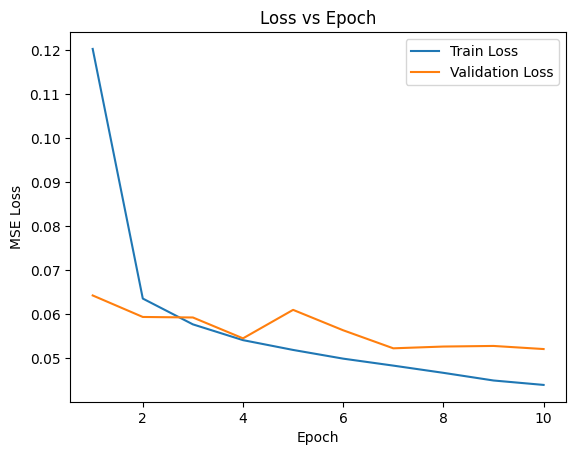

In [21]:
epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

LOADING THE BEST MODEL

In [22]:
model.load_state_dict(torch.load("best_lstm.pth"))
model.eval()

with torch.no_grad():

    x_batch, y_batch = next(iter(val_loader))

    x_batch = x_batch.to(device)

    prediction = model(x_batch)

prediction = prediction.cpu().numpy()
target = y_batch.numpy()

prediction = prediction * scaler.scale_[temperature_column] + scaler.mean_[temperature_column]
target = target * scaler.scale_[temperature_column] + scaler.mean_[temperature_column]

FORECAST VISUALISATION

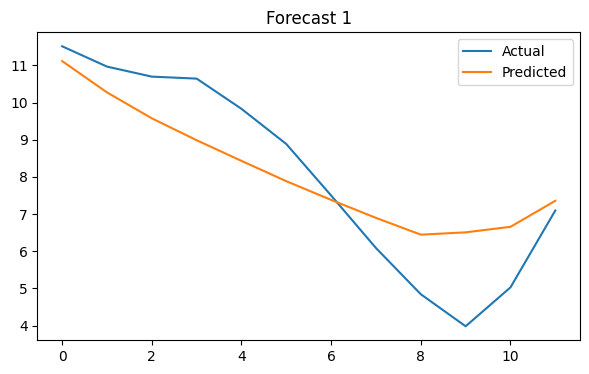

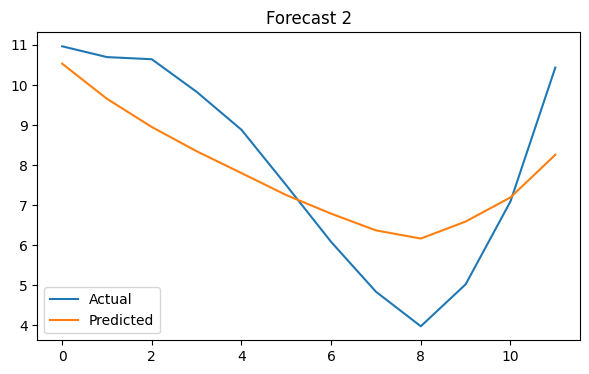

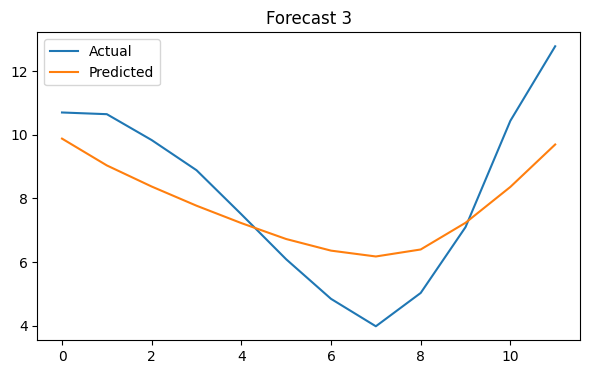

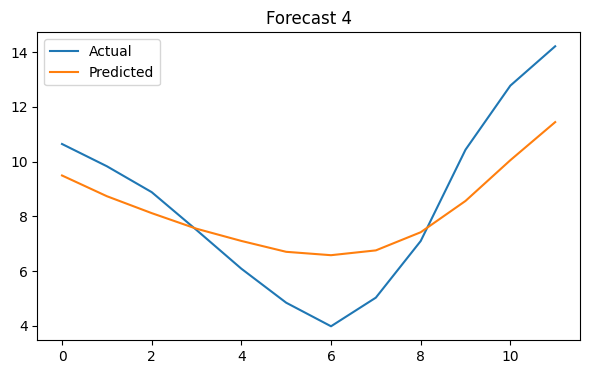

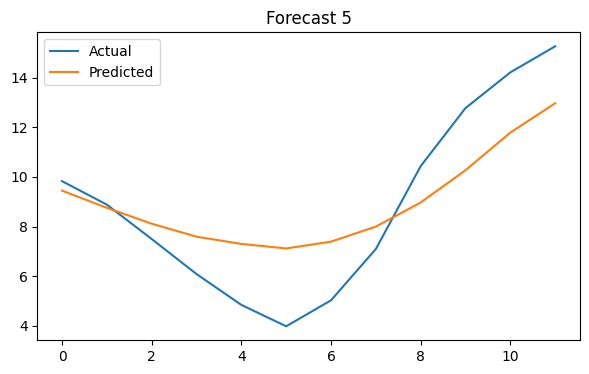

In [23]:
for i in range(5):

    plt.figure(figsize=(7,4))

    plt.plot(target[i], label="Actual")

    plt.plot(prediction[i], label="Predicted")

    plt.title(f"Forecast {i+1}")

    plt.legend()

    plt.savefig(f"forecast_{i+1}.png", dpi=300, bbox_inches="tight")

    plt.show()